# Softmax Regression from Scratch (NumPy)

## Setup

In [16]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

from softmax import one_hot, cross_entropy, evaluate_gradients_and_loss, learning_schedule

In [17]:
import numpy as np

np.random.seed(42)

## Load dataset

First, let's load our dataset (we use the Iris dataset) and set hyperparameters: num_epochs, batch_size and initialize the weight matrix $\Theta$:

$ \Theta = \begin{bmatrix}
\theta_{0}^{(0)} & \theta_{1}^{(0)} & \theta_{2}^{(0)} \\
\theta_{0}^{(1)} & \theta_{1}^{(1)} & \theta_{2}^{(1)} \\
... & ... & ... \\
\theta_{0}^{(K)} & \theta_{1}^{(K)} & \theta_{2}^{(K)} \\
\end{bmatrix}$

Where:
* $\theta_{i}^{(j)}$ - weight i for class j
* $K$ - num of classes

Use sklearn only to load the dataset:

In [18]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [19]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target.to_numpy()

m = X.shape[0]

num_epochs = 5000
matrix_weight = np.array([np.random.randn(1, 3)[0] for _ in range(len(np.unique(y)))])
matrix_weight

array([[ 0.49671415, -0.1382643 ,  0.64768854],
       [ 1.52302986, -0.23415337, -0.23413696],
       [ 1.57921282,  0.76743473, -0.46947439]])

Add a column of ones for the bias

In [20]:
X = np.c_[np.ones((m, 1)), X]
X[:5]

array([[1. , 1.4, 0.2],
       [1. , 1.4, 0.2],
       [1. , 1.3, 0.2],
       [1. , 1.5, 0.2],
       [1. , 1.4, 0.2]])

## Train-test split

In [21]:
test_size = 0.2
len_test = int(test_size * X.shape[0])
len_train = X.shape[0] - len_test

shuffle = np.random.permutation(X.shape[0])
X = X[shuffle, :]
y = y[shuffle]

X_train, y_train = X[:len_train], y[:len_train]
X_train_before_scaling = X_train.copy()
X_test, y_test = X[len_train:], y[len_train:]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((120, 3), (120,), (30, 3), (30,))

## Data preparation

In [22]:
y_train_ohe = one_hot(y_train)
y_train[:5], y_train_ohe[:5]

(array([2, 1, 1, 2, 0]),
 array([[0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [1., 0., 0.]]))

Scaling X_train:

In [23]:
mean_X_train = X_train[:, 1:].mean(axis=0, keepdims=True)
std_X_train = X_train[:, 1:].std(axis=0, keepdims=True)

X_train[:, 1:] = (X_train[:, 1:] - mean_X_train) / std_X_train
X_train[:5]

array([[ 1.        ,  0.78387877,  0.89980072],
       [ 1.        ,  0.44632332,  0.13581898],
       [ 1.        ,  0.5588418 ,  0.51780985],
       [ 1.        ,  0.95265649,  1.1544613 ],
       [ 1.        , -1.29771318, -1.39214451]])

## Model training

We will use batch gradient descent

First, we evaluate scores. Score for one class k:

$s_{k}(x) = (\theta^{(k)})^T x$

For example, score for class zero: 

$s_{0}(x) = (\theta^{(0)})^T x$

For all classes:

$X \cdot \Theta^T = \begin{bmatrix}
x_{0}^{(0)} & x_{1}^{(0)} & x_{2}^{(0)} \\
x_{0}^{(1)} & x_{1}^{(1)} & x_{2}^{(1)} \\
... & ... & ... \\
x_{0}^{(m)} & x_{1}^{(m)} & x_{2}^{(m)} \\
\end{bmatrix}
\cdot 
\begin{bmatrix}
\theta_{0}^{(0)} & \theta_{0}^{(1)} & ... & \theta_{0}^{(K)} \\
\theta_{1}^{(0)} & \theta_{1}^{(1)} & ... & \theta_{1}^{(K)} \\
\theta_{2}^{(0)} & \theta_{2}^{(1)} & ... & \theta_{2}^{(K)} \\
\end{bmatrix} =
\begin{bmatrix}
x_0^{(0)}\theta_0^{(0)} + x_1^{(0)}\theta_1^{(0)} + x_2^{(0)}\theta_2^{(0)} & x_0^{(0)}\theta_0^{(1)} + x_1^{(0)}\theta_1^{(1)} + x_2^{(0)}\theta_2^{(1)} & \dots & x_0^{(0)}\theta_0^{(K)} + x_1^{(0)}\theta_1^{(K)} + x_2^{(0)}\theta_2^{(K)} \\
x_0^{(1)}\theta_0^{(0)} + x_1^{(1)}\theta_1^{(0)} + x_2^{(1)}\theta_2^{(0)} & x_0^{(1)}\theta_0^{(1)} + x_1^{(1)}\theta_1^{(1)} + x_2^{(1)}\theta_2^{(1)} & \dots & x_0^{(1)}\theta_0^{(K)} + x_1^{(1)}\theta_1^{(K)} + x_2^{(1)}\theta_2^{(K)} \\
\dots & \dots & \dots & \dots \\
x_0^{(m)}\theta_0^{(0)} + x_1^{(m)}\theta_1^{(0)} + x_2^{(m)}\theta_2^{(0)} & x_0^{(m)}\theta_0^{(1)} + x_1^{(m)}\theta_1^{(1)} + x_2^{(m)}\theta_2^{(1)} & \dots & x_0^{(m)}\theta_0^{(K)} + x_1^{(m)}\theta_1^{(K)} + x_2^{(m)}\theta_2^{(K)}
\end{bmatrix} =
 \begin{bmatrix}
s_{0}(x^{(0)}) & s_{1}(x^{(0)}) & ... & s_{K}(x^{(0)}) \\
s_{0}(x^{(1)}) & s_{1}(x^{(1)}) & ... & s_{K}(x^{(1)}) \\
... & ... & ... & ... \\
s_{0}(x^{(m)}) & s_{1}(x^{(m)}) & ... & s_{K}(x^{(m)}) \\
\end{bmatrix} =
\begin{bmatrix}
s(x^{(0)}) \\
s(x^{(1)}) \\
... \\
s(x^{(m)}) \\
\end{bmatrix}$

Then we estimate the probability $\hat{p}_{k}$ for each class:

$\hat{p}_{k} = \sigma(s(x))_{k} = \frac{exp(s_{k}(x))}{\sum_{j=0}^{K}exp(s_{j}(x))}$

For BGD we use the cross-entropy cost function:

$J(\Theta) = -\frac{1}{m}\sum_{i=0}^{m}\sum_{k=0}^{K}y_{k}^{(i)}log(\hat{p}_{k}^{(i)})$

The gradient vector of this cost function:

$\nabla_{\theta^{(k)}}J(\Theta) = \frac{1}{m}\sum_{i=0}^{m}(\hat{p}_{k}^{(i)} - y_{k}^{(i)})x^{(i)}$

In [24]:
alpha = 0.01

all_loss_train = []
all_loss_valid = []
all_accuracy_train = []
all_accuracy_valid = []

best_val_accuracy = float("-inf")
best_val_loss = None
best_epoch = None
best_matrix_weight = None

shuffled = np.random.permutation(X_train.shape[0])
X_shuffled = X_train[shuffled, :]
y_shuffled = y_train_ohe[shuffled]

valid_size = 0.2
len_valid = int(X_train.shape[0] * valid_size)
len_train = X_train.shape[0] - len_valid

X_train_shfld = X_shuffled[:len_train]
y_train_shfld = y_shuffled[:len_train]
X_valid_shfld = X_shuffled[len_train:]
y_valid_shfld = y_shuffled[len_train:]

for epoch in range(num_epochs):
    if epoch % 500 == 0:
        print(f"Epoch: {epoch}")

    shuffled = np.random.permutation(X_train_shfld.shape[0])
    X_train_shfld = X_train_shfld[shuffled, :]
    y_train_shfld = y_train_shfld[shuffled]

    gradients, loss = evaluate_gradients_and_loss(X_train_shfld, y_train_shfld, matrix_weight)
    all_loss_train.append(loss)
    gradients_with_l2 = (
        gradients
        + np.c_[np.zeros(matrix_weight.shape[0]), 2 * alpha * matrix_weight[:, 1:] / X_train_shfld.shape[0]] 
    )

    learning_rate = learning_schedule(epoch)
    matrix_weight -= learning_rate * gradients_with_l2

    preds_train = np.argmax(X_train_shfld @ matrix_weight.T, axis=1)
    train_accuracy = (preds_train == np.argmax(y_train_shfld, axis=1)).sum() / y_train_shfld.shape[0]
    all_accuracy_train.append(train_accuracy)

    # early stopping
    scores_valid = X_valid_shfld @ matrix_weight.T 
    scores_valid = scores_valid - scores_valid.max(axis=1, keepdims=True)
    preds_valid = np.argmax(scores_valid, axis=1)
    valid_accuracy = (preds_valid == np.argmax(y_valid_shfld, axis=1)).sum() / y_valid_shfld.shape[0]
    all_accuracy_valid.append(valid_accuracy)

    exp_valid_scores = np.exp(scores_valid)
    proba_valid = exp_valid_scores / exp_valid_scores.sum(axis=1, keepdims=True)
    loss_valid = cross_entropy(proba_valid, y_valid_shfld)
    all_loss_valid.append(loss_valid)

    if valid_accuracy > best_val_accuracy:
        best_val_accuracy = valid_accuracy
        best_val_loss = loss_valid
        best_epoch = epoch
        best_matrix_weight = matrix_weight.copy()

all_loss_train = np.array(all_loss_train)
all_loss_valid = np.array(all_loss_valid)
all_accuracy_train = np.array(all_accuracy_train)
all_accuracy_valid = np.array(all_accuracy_valid)
print(all_loss_train.shape, all_loss_valid.shape, all_accuracy_train.shape, all_accuracy_valid.shape)
print(best_val_accuracy.round(2))

Epoch: 0
Epoch: 500
Epoch: 1000
Epoch: 1500
Epoch: 2000
Epoch: 2500
Epoch: 3000
Epoch: 3500
Epoch: 4000
Epoch: 4500
(5000,) (5000,) (5000,) (5000,)
1.0


Loss and accuracy plot

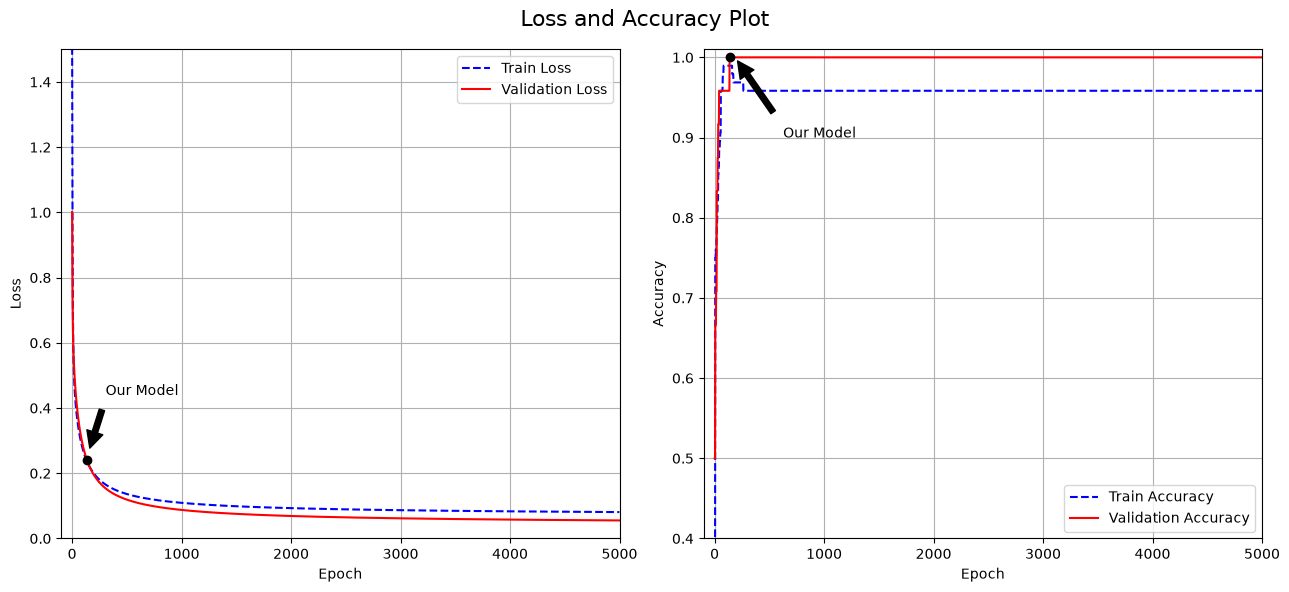

In [25]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(13, 6), layout="tight")
axes[0].plot(all_loss_train, "b--", label="Train Loss")
axes[0].plot(all_loss_valid, "r-", label="Validation Loss")
axes[0].plot(best_epoch, best_val_loss, "ko")
axes[0].annotate(
    "Our Model",
    xy=(best_epoch, best_val_loss + 1e-2),
    xytext=(best_epoch + 170, best_val_loss + 0.2),
    arrowprops=dict(facecolor="black", shrink=0.15),
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_xlim(-100, 5000)
axes[0].set_ylim(0, 1.5)
axes[1].plot(all_accuracy_train, "b--", label="Train Accuracy")
axes[1].plot(all_accuracy_valid, "r-", label="Validation Accuracy")
axes[1].plot(best_epoch, best_val_accuracy, "ko")
axes[1].annotate(
    "Our Model",
    xy=(best_epoch, best_val_accuracy + 1e-2),
    xytext=(best_epoch + 490, best_val_accuracy - 0.1),
    arrowprops=dict(facecolor="black", shrink=0.15),
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_xlim(-100, 5000)
axes[1].set_ylim(0.4, 1 + 1e-2)
axes[0].grid(); axes[1].grid()
axes[0].legend(loc="upper right"); axes[1].legend(loc="lower right")
plt.suptitle("Loss and Accuracy Plot", fontsize=16)
plt.show()

Decision Boundary Plot

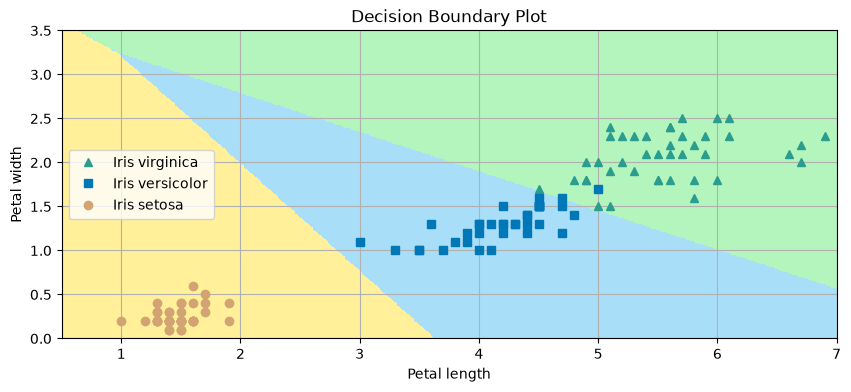

In [26]:
from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(["#FFF099", "#A9DEF9", "#B3F5BC"])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                    np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[np.ones(100_000), x0.ravel(), x1.ravel()]
X_new[:, 1:] = (X_new[:, 1:] - mean_X_train) / std_X_train

y_scores = X_new @ best_matrix_weight.T
y_predict = np.argmax(y_scores, axis=1)

zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X_train_before_scaling[y_train == 2, 1], X_train_before_scaling[y_train == 2, 2], color="#2A9D8F", marker="^", linestyle="", label="Iris virginica")
plt.plot(X_train_before_scaling[y_train == 1, 1], X_train_before_scaling[y_train == 1, 2], color="#0077B6", marker="s", linestyle="", label="Iris versicolor")
plt.plot(X_train_before_scaling[y_train == 0, 1], X_train_before_scaling[y_train == 0, 2], color="#D4A373", marker="o", linestyle="", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("Decision Boundary Plot")
plt.axis([0.5, 7, 0, 3.5])
plt.legend(loc="center left")
plt.grid()
plt.show()

## Final model in test set

In [27]:
finally_matrix_weight = best_matrix_weight.copy()

X_test_tr = np.c_[X_test[:, 0], (X_test[:, 1:] - mean_X_train) / std_X_train]
test_preds = np.argmax(X_test_tr @ finally_matrix_weight.T, axis=1)
accuracy = (test_preds == y_test).sum() / y_test.shape[0]
print(f"Accuracy in test set: {accuracy.round(2)}")

Accuracy in test set: 0.93


## Comparison with sklearn

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

params_grid = {
    "logisticregression__C": list(np.arange(1, 1000, 10))
}

softmax_reg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

grid_search = GridSearchCV(
    softmax_reg_pipeline,
    params_grid,
    scoring="accuracy",
    cv=3
)

grid_search.fit(X_train_before_scaling[:, 1:], y_train)

softmax_reg_pipeline = grid_search.best_estimator_
preds = softmax_reg_pipeline.predict(X_test[:, 1:])
print(f"Accuracy in test set: {round(accuracy_score(y_test, preds), 2)}")

Accuracy in test set: 0.9
